# <span style="color:rgb(160,0,86)">Zeitreihenanalyse</span>

***

## <span style="color:rgb(160,0,86)">Lernziele</span>

- Sie wissen was **eine Zeitreihe** ist.
- Für einfache Zeitreihen können Sie eine **Trendlinie** und eine **Saisonfigur** bestimmen.  
- Sie können Zeitreihen mit **gleitenden Mittelwerten** oder **exponentiell** glätten.  

***

### <span style="color:rgb(160,0,86)">Was ist eine Zeitreihe?</span>

Eine **Zeitreihe** ist eine Folge von **zeitlich hintereinander** erhobenen Beobachtungswerten eines Merkmals bei einer statisischen Einheit. Oft haben die Zeitwerte regelmässige Abstände.     

#### <span style="color:rgb(160,0,86)">Typische Beispiele:</span>

- Tägliche Schlusskurse eines börsengehandelten Wertpapiers.
- Die monatlich festgestellt Arbeitslosenzahl in der Schweiz.
- Die Quartalsumsätze eines Unternehmens.
- Die jährliche Fördermenge einer Erdölraffinerie.
- Aktionen auf einem Computersystem in einer Logdatei
- Sensorwerte einer Traffic-Messungen. 

***

In der **Zeitreihenanalyse** werden Zeireihen auf Gesetzmässigkeiten untersucht, die sich aus der zeitlichen Abfolge der Beobachtungen ergeben. 

Die einfachsten Verfahren zielen darauf ab, den Zeitreihenverlauf auf systematische Komponenten wie **Trend** und **Saisoneinflüsse** zurückzuführen. Neben diesen systematischen Komponenten wird noch eine Restkomponente berücksichtigt, in der alle nicht systematischen **zufälligen** Einflüsse auf die Zeitreihe zusammengefasst werden.

Im **additiven Modell der Zeitreihe** wird also eine Schätzung wie folgt gemacht:
$$\pmb{\hat{y}(t)}\;=\;\textbf{glatte Komponente }\, \pmb{g(t)}\; + \;\textbf{zyklische Komponente }\, \pmb{s(t)}$$

### <span style="color:rgb(160,0,86)">Eine Zeitreihe zur Kohlendioxidkonzentration in der Atmosphäre.</span>

Die Messstation Mauna Loa ist eine meteorologische Forschungsstation in 3397 Metern Höhe auf dem Vulkan Mauna Loa auf Hawaii (https://gml.noaa.gov/ccgg/trends/data.html).

<p style="text-align: center"><img src="Bilder/MaunaLoa.png"></p>

Seit 1958 werden dort kontinuierlich $\mathsf{CO}_2$-Messungen durchgeführt, was das **Global Monitoring Laboratory** zu den längsten kontinuierlichen Zeitreihen der Welt macht.

Wenn wir die Daten wie gewohnt mit <tt><strong>read_csv()</strong></tt> laden, entsteht eine Fehlermeldung. Das Problem ist, dass in der csv-Datei **Kommentare** mit dem **Token #** eingefügt wurden.  
- Damit das Einlesen der Daten dennoch fehlerfrei funktioniert, können wir mit dem **Paramter** <tt><strong>comment</strong></tt> angeben, welches Token für Kommentare verwendet wird. Dann werden beim Parsen der Datei alle Zeichen nach dem Token **#** zeilenweise ignoriert:

In [7]:
#Mauna Loa CO2-Aufzeichnungen
import numpy as np
import pandas as pd
CO2 = pd.read_csv("Daten/co2_mm_mlo.csv", comment="#")

CO2

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1958.2027,315.71,314.44,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.69,-1,-9.99,-0.99
3,1958,6,1958.4548,317.27,315.15,-1,-9.99,-0.99
4,1958,7,1958.5370,315.87,315.20,-1,-9.99,-0.99
...,...,...,...,...,...,...,...,...
801,2024,12,2024.9583,425.40,426.12,28,0.70,0.25
802,2025,1,2025.0417,426.65,426.34,29,0.62,0.22
803,2025,2,2025.1250,427.09,426.16,24,0.64,0.25
804,2025,3,2025.2083,428.15,426.67,27,1.13,0.42


Die **Spalten** <tt><strong>(year,month)</strong></tt> bilden zwar einen **primary key** der Datenbank. 
- Für die zeitliche Abfolge der **mittleren monatlichen CO2-Werte** in der **Spalte** <tt><strong>average</strong></tt> ist aber die **einzige nummerisch aufsteigende *** **Spalte** <tt><strong>decimal date</strong></tt> als Zeitangabe besser geeignet.

Daher schneiden wir aus dem DataFrame die Spalten <tt>(year,month,decimal date,average)</tt> aus und filtern für die weitere Analyse nur die **Daten ab dem Jahr 1990**:

In [8]:
df = CO2[["year","month","decimal date","average"]][CO2["year"]>=1990]
df.head()

,year,month,decimal date,average
382,1990,1,1990.0417,353.86
383,1990,2,1990.1250,355.10
384,1990,3,1990.2083,355.75
385,1990,4,1990.2917,356.38
386,1990,5,1990.3750,357.38


Einen ersten Überblick gewinnen wir aus deinem Streudiagramm, in dem auf der $\pmb{x}$-**Achse** die **Zeit als decimal date** und auf der $\pmb{y}$-**Achse** die **mittleren monatlichen CO2-Werte** eingezeichnet werden:

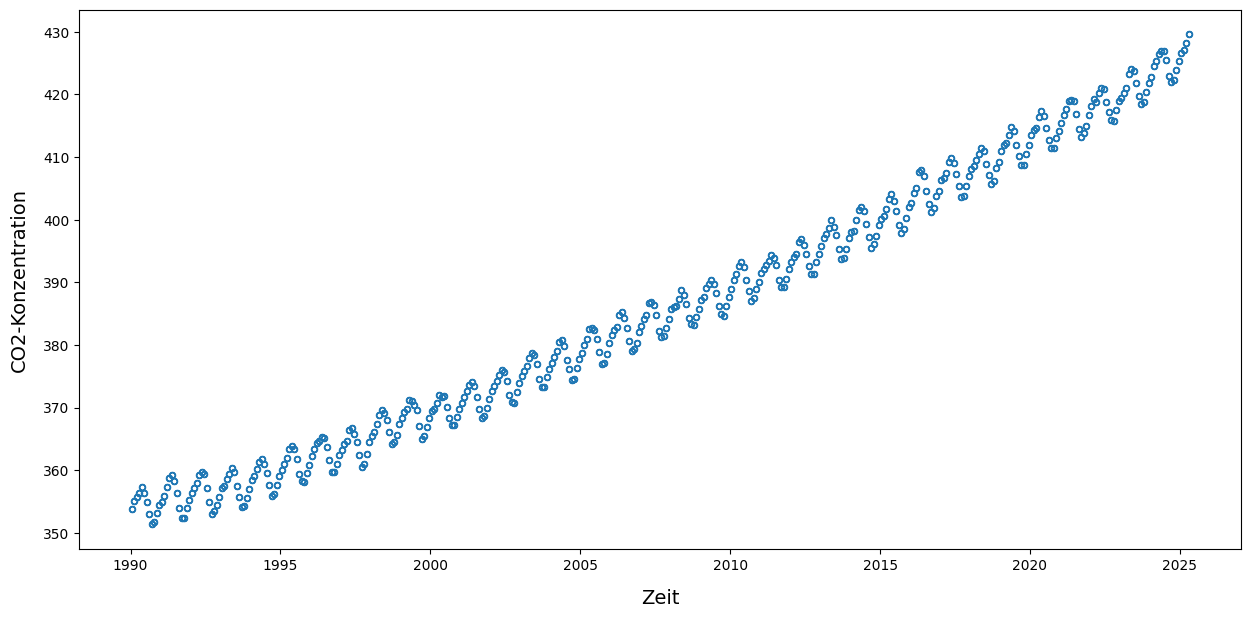

In [9]:
import matplotlib.pyplot as plt

# Figurobjekt erstellen
fig = plt.figure(figsize=(15,7))

# Koordinatensystem erstellen
axi = fig.add_subplot(1,1,1)

# Streudiagramm zeichen
df.plot.scatter(x = "decimal date", y = "average", ax = axi, marker="$\u25EF$")

# Achsen beschriften
axi.set_xlabel("Zeit",size=14,labelpad=12)
axi.set_ylabel("CO2-Konzentration",size=14,labelpad=10)

# Figur zeigen
plt.show()

Aus der Graphik erkennen wir einen **steigenden Trend mit jährlichen Schwankungen**. 
- Ein **lineares Modell** $$\texttt{averageCO2} \;\,=\;\, a\cdot \texttt{Zeit} + b$$ kann die leichte linkskrümmung (konvexer Trend) nicht abbilden. Mit einer **Potenzfunktion** können wir diesen Effekt modellieren: $$\texttt{averageCO2} \;\,=\;\, a\cdot \texttt{Zeit}^r + b$$

Mit der **Methode der kleinsten Quadrate** bestimmen wir die Paramter für beide Modelle. Damit die numerische Optimierung mit kleineren Zeitwerten berechnet wird, **verschieben wir die Zeitangaben** um 1989 Jahre:

In [10]:
from scipy.optimize import minimize 

# CO2-Konzentration = a * Zeit + b (linear)
def model_linear(time,a=1,b=0):
    
    return a*time + b

# CO2-Konzentration = a * Zeit^r + b (potenz)
def model_potenz(time,a=1,r=1,b=0): 
    return a*(time**r) + b

# Zeitverschiebung => kleinere Werte
t = df["decimal date"] - 1989

# parameter = [a,b]
def RSS_linear(parameter):
    residuen = df["average"] - model_linear(t,a=parameter[0],
                                              b=parameter[1])
    return (residuen**2).sum()

# parameter = [a,r,b]
def RSS_potenz(parameter):
    residuen = df["average"] - model_potenz(t,a=parameter[0],
                                              r=parameter[1],
                                              b=parameter[2])
    return (residuen**2).sum()    

# Berechne die Parameter für das lineare Modell
fit_linear = minimize(RSS_linear,x0=[0,0],method = 'powell')
print("Minimierung RSS_linear war erfolgreich:",fit_linear.success)

# Berechne die Parameter für das Modell mit der Potenzfunktion
fit_potenz = minimize(RSS_potenz,x0=[1,1,300],method = 'powell')
print("Minimierung RSS_potenz war erfolgreich:",fit_potenz.success)

Minimierung RSS_linear war erfolgreich: True
Minimierung RSS_potenz war erfolgreich: True


Nun können wir die **Prädiktorfunktionen** implementieren und **als Trendlinien** in die Daten zeichnen:  

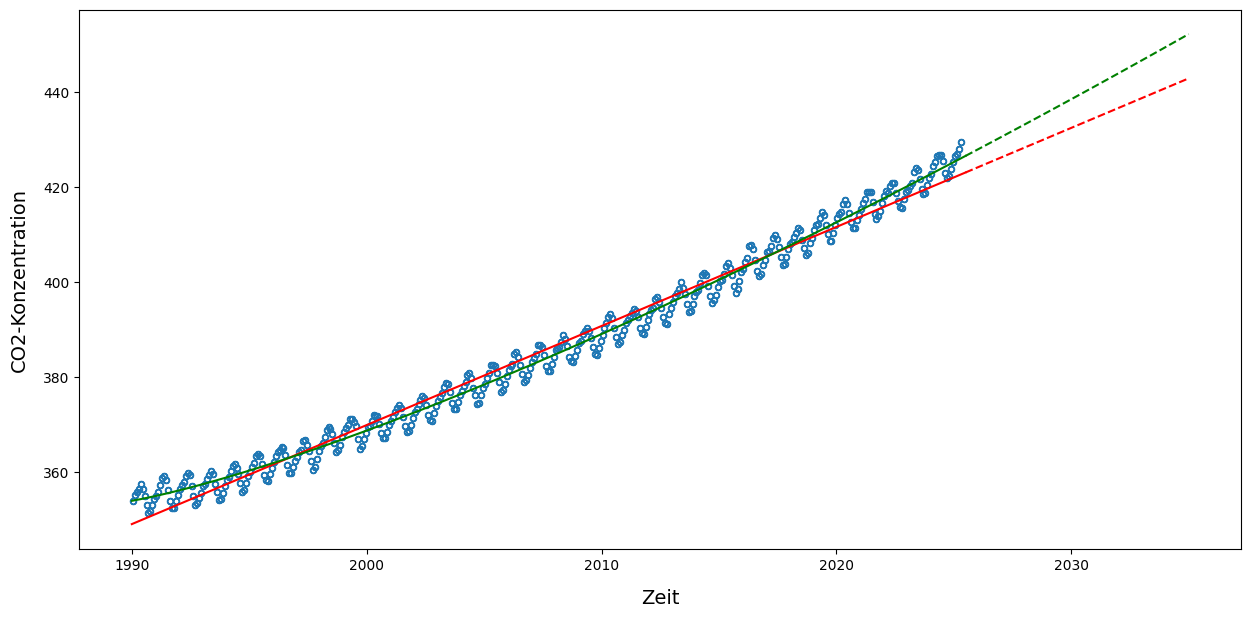

In [11]:
# CO2-Werte mit linearem Modell schätzen
def predict_linear(x):
    return model_linear(x - 1989,a=fit_linear.x[0],
                                 b=fit_linear.x[1])

# CO2-Werte mit Potenzfunktion als Modell schätzen
def predict_potenz(x):
    return model_potenz(x - 1989,a=fit_potenz.x[0],
                                 r=fit_potenz.x[1],
                                 b=fit_potenz.x[2])

# Figurobjekt erstellen
fig = plt.figure(figsize=(15,7))

# Koordinatensystem erestellen
axi = fig.add_subplot(1,1,1)

# Streudiagramm für die CO2-Werte zeichen
df.plot.scatter(x = "decimal date", y = "average", ax = axi, marker="$\u25EF$")

# Koordinaten für die historischen Daten zeichnen
x = np.linspace(1990,2025.5,100)
y_lin = predict_linear(x) # lineare Funktion
y_pot = predict_potenz(x) # Potenzfunktion
axi.plot(x,y_lin,color="red",lw=1.5)
axi.plot(x,y_pot,color="green",lw=1.5)

# Koordinaten für zukünftige Daten bis 2035 zeichnen
x_pred = np.linspace(2025.5,2035,100)
y_lin_pred = predict_linear(x_pred) # lineare Funktion
y_pot_pred = predict_potenz(x_pred) # Potenzfunktion
axi.plot(x_pred,y_lin_pred,color="red",lw=1.5,linestyle='dashed')
axi.plot(x_pred,y_pot_pred,color="green",lw=1.5,linestyle='dashed')

# Achsen beschriften
axi.set_xlabel("Zeit",size=14,labelpad=12)
axi.set_ylabel("CO2-Konzentration",size=14,labelpad=10)

# Figur zeigen
plt.show()

Wir bestimmen für beide Modelle **das Bestimmtheitsmass**:

In [12]:
R_squared_linear = (predict_linear(df["decimal date"]).var() / 
                    df["average"].var()) 
R_squared_potenz = (predict_potenz(df["decimal date"]).var() / 
                    df["average"].var())

print("Bestimmtheitsmass für das lin-Modell:", round(R_squared_linear,4))
print("Bestimmtheitsmass für das pot-Modell:", round(R_squared_potenz,4))

Bestimmtheitsmass für das lin-Modell: 0.9824
Bestimmtheitsmass für das pot-Modell: 0.9895


Das **nicht lineare Modell mit der Potenzfunktion** bildet den Zeitverlauf besser ab.

Die **saisonalen Schwankungen** sind die Residuen. 
- Wir ergänzen diese als weitere **Spalte** <tt><strong>residum</strong></tt> im DataFrame **df**: 

In [13]:
df["residum"] = df["average"] - predict_potenz(df["decimal date"])
df.head(12)

,year,month,decimal date,average,residum
382,1990,1,1990.0417,353.86,-0.105613
383,1990,2,1990.1250,355.10,1.057848
384,1990,3,1990.2083,355.75,1.629608
385,1990,4,1990.2917,356.38,2.179655
386,1990,5,1990.3750,357.38,3.098255
387,1990,6,1990.4583,356.39,2.025379
388,1990,7,1990.5417,354.89,0.440985
389,1990,8,1990.6250,353.06,-1.474670
390,1990,9,1990.7083,351.38,-3.241638
391,1990,10,1990.7917,351.69,-3.019978


Um die **zyklische Kompenente** zu bestimmen, **mitteln** wir all die **Residuen** $\,\pmb{r_t}\,$ **für gleiche Monate**
$$\begin{align*}
\pmb{\bar{r}}_{\texttt{Januar}} &\;\,=\;\, \dfrac{1}{|\{t :  t \,\text{ ist ein Januar}\}|}\sum_{\substack{t \text{ ist ein}\rule{0cm}{0.6cm}\\ \text{Januar}\rule{0cm}{0.5cm}}}r_t\\ 
\pmb{\bar{r}}_{\texttt{Februar}} &\;\,=\;\, \dfrac{1}{|\{t : t \,\text{ ist ein Februar}\}|}\sum_{\substack{t \text{ ist ein}\rule{0cm}{0.6cm}\\ \text{Februar}\rule{0cm}{0.5cm}}}r_t\rule{0cm}{1.5cm}\\ 
 & \;\;\,\vdots \\
\pmb{\bar{r}}_{\texttt{Dezember}} &\;\,=\;\, \dfrac{1}{|\{t : t \,\text{ ist ein Dezember}\}|}\sum_{\substack{t \text{ ist ein}\rule{0cm}{0.6cm}\\ \text{Dezember}\rule{0cm}{0.5cm}}}r_t\rule{0cm}{1.15cm}\end{align*}$$
und speichern diese **zwölf mittleren Abweichungen von der Trendlinie** in der Liste $$\text{means} \,\;=\;\, [\,\pmb{\bar{r}}_{\texttt{Januar}}\,, \;\pmb{\bar{r}}_{\texttt{Februar}}\,,\; \ldots, \;\pmb{\bar{r}}_{\texttt{Dezember}}]$$

In [14]:
# mittlere Residuen für alle Monate
means = [df["residum"][df["month"]==i].mean() for i in range(1,13)]

Nun ergänzen wir in **df** eine **Spalte** <tt><strong>mean_seasonal<strong></tt>, die für alle Monate von 1990 Januar bis April 2025 die **mittlere Abweichung von der Trendline** enthält.  
- Wir erstellen einen **Vektor** mit den **passenden Werten**, der gleichviele Einträge hat, wie das DataFrame **df** Zeilen hat:   

In [15]:
# Liste der mittleren Residuen für gleich viele Monate wie in df
mean_seasonal = ((df.shape[0]//12+1)*means)[0:df.shape[0]]

# In df als Spalte ergänzen
df["mean_seasonal"] = np.array(mean_seasonal)

df

,year,month,decimal date,average,residum,mean_seasonal
382,1990,1,1990.0417,353.86,-0.105613,0.208098
383,1990,2,1990.1250,355.10,1.057848,0.871601
384,1990,3,1990.2083,355.75,1.629608,1.531977
385,1990,4,1990.2917,356.38,2.179655,2.712081
386,1990,5,1990.3750,357.38,3.098255,3.112927
...,...,...,...,...,...,...
801,2024,12,2024.9583,425.40,0.184571,-0.780266
802,2025,1,2025.0417,426.65,1.218060,0.208098
803,2025,2,2025.1250,427.09,1.441660,0.871601
804,2025,3,2025.2083,428.15,2.285113,1.531977


Damit wir eine **Prädiktorfunktion mit saisonaler Schwankung** implementieren können, brauchen wir die genaue Berechung der Werte in der Spalte <tt><strong>decimal date</strong></tt>. Es gilt:
$$\begin{align*}\texttt{"Januar"} &\quad\widehat{=}\quad \dfrac{1}{24} + \dfrac{0}{12} \;\approx\; 0.0417\qquad (\text{gerundet auf 4 Dezimalstellen})\\
\texttt{"Februar"} &\quad\widehat{=}\quad \dfrac{1}{24} + \dfrac{1}{12}\;\approx\; 0.1250 \rule{0cm}{1.25cm}\\ \texttt{"März"} &\quad\widehat{=}\quad \dfrac{1}{24} + \dfrac{2}{12}\;\approx\; 0.2083 \rule{0cm}{1.25cm}\\ & \,\;\;\;\;\vdots \\ \texttt{"Dezember"} &\quad\widehat{=}\quad \dfrac{1}{24} + \dfrac{11}{12}\;\approx\; 0.9583 \rule{0cm}{1.25cm}\end{align*}$$
Damit können wir den **Index** $\,\pmb{x}\,$ **des Monats** aus dem Dezimalwert bestimmen: $$\begin{align*}\dfrac{1}{24} + \dfrac{x}{12} &\;\,=\;\,\texttt{MonatDezimalwert} \\ \dfrac{1}{2} + x &\;\,=\;\,12 \cdot\texttt{MonatDezimalwert}\rule{0cm}{1.25cm} \\
x &\;\,=\;\,12\cdot\texttt{MonatDezimalwert} -\dfrac{1}{2}\rule{0cm}{1.25cm}
\end{align*}$$

In [16]:
def predictCO2(decimalDate):
    # Trend berechnen
    trend  = predict_potenz(decimalDate)
    
    # Dezimalwert des ersten Monats bestimmen
    decimalMonat = decimalDate[0] - np.floor(decimalDate[0])
    
    # Index des ersten Monats bestimmen
    ersterIdx = int(round(12 * decimalMonat - 1/2,0))
    
    # saisonale Schwankung berechnen
    season = np.array([means[(ersterIdx + i)%12] 
                       for i in range(len(decimalDate))])
    
    return trend + season

Mit dieser Prädiktorfunktion berücksichtigen wir nun auch die saisonalen Schwankungen. 
- Wir können die **historischen Daten** und die **Schätzungen** zeichnen:

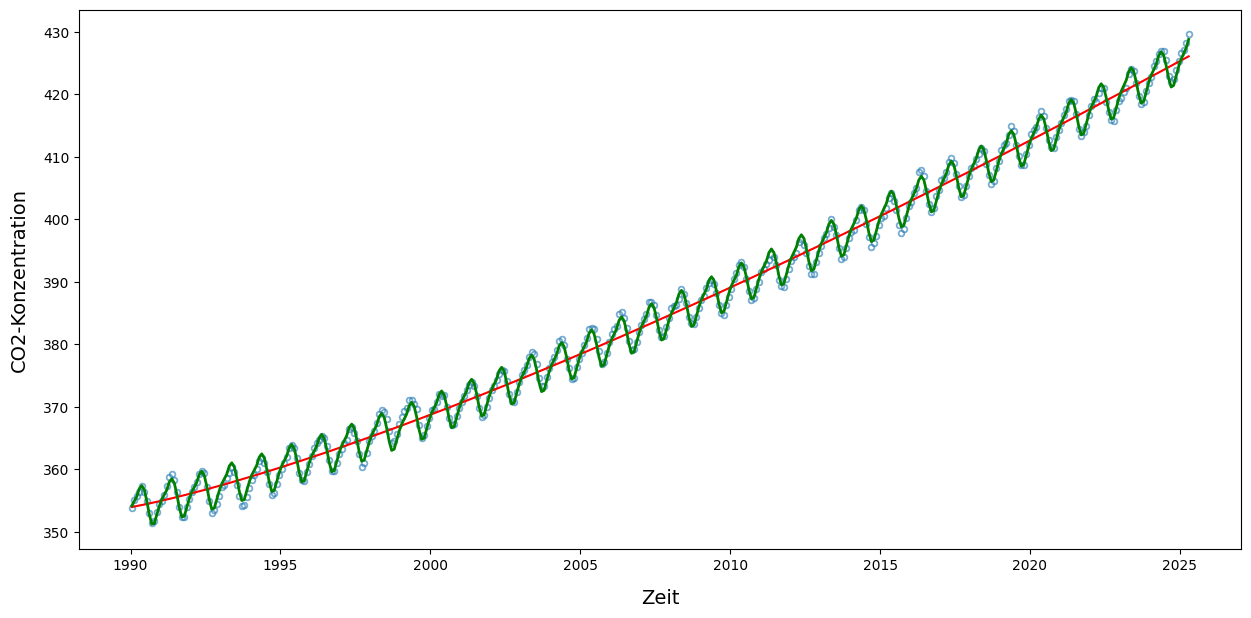

In [17]:
# Figurobjekt erstellen
fig = plt.figure(figsize=(15,7))

# Koordinatensystem erstellen
axi = fig.add_subplot(1,1,1)

# Streudiagramm für die historischen Daten zeichnen
df.plot.scatter(x = "decimal date", y = "average", 
                ax = axi, marker="$\u25EF$",alpha=0.5)

# Koordinaten der Schätzungen berechnen
x = df["decimal date"].values
y = predictCO2(x)            # Trendlinie mit saisonaler Schwankung
y_trend = predict_potenz(x)  # nur Trendlinie

# Schätzungen zeichnen
axi.plot(x,y_trend,color="red",lw=1.5)
axi.plot(x,y,color="green",lw=2)

# Achsen beschriften
axi.set_xlabel("Zeit",size=14,labelpad=12)
axi.set_ylabel("CO2-Konzentration",size=14,labelpad=10)

# Figur zeigen
plt.show()

Das **Bestimmtheitsmass** zeigt, dass die Schätzungen mit saisonaler Schwankung besser sind:

In [18]:
# Bestimmtheitsmass ohne saisonale Schwankung
R_squared_trend = predict_potenz(df["decimal date"]).var() / df["average"].var()

# Bestimmtheitsmass mit saisonale Schwankung
R_squared_CO2 = predictCO2(df["decimal date"].values).var() / df["average"].var()

print("Bestimmtheitsmass ohne saisonaler Schwankung :",round(R_squared_trend,4))
print("Bestimmtheitsmass mit saisonaler Schwankung  :",round(R_squared_CO2,4))

Bestimmtheitsmass ohne saisonaler Schwankung : 0.9895
Bestimmtheitsmass mit saisonaler Schwankung  : 0.996


Mit der Prädiktorfunktion können wir nun die **CO2-Werte in naher Zukunft prognostizieren**:

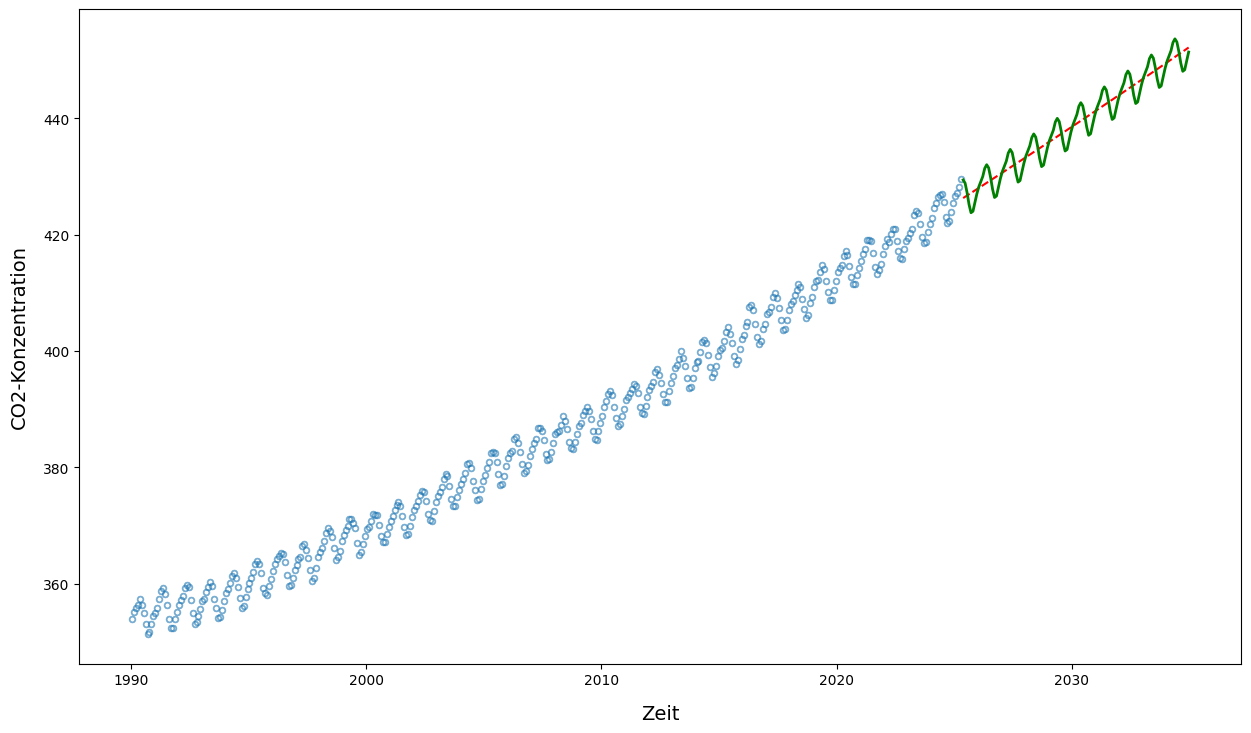

In [19]:
# Figurobjekt erstellen
fig = plt.figure(figsize=(15,8.5))

# Koordinatensystem erstellen
axi = fig.add_subplot(1,1,1)

# Streudiagramm für die historischen Daten zeichnen
df.plot.scatter(x = "decimal date", y = "average", 
                ax = axi, marker="$\u25EF$",alpha=0.5)

# Koordinaten für zukünftige CO2-Werte (Mai 2025 bis Dezember 2034)
x_pred = np.round(np.arange(2025 + 1/24 + 4/12, 2035, 1/12), 4)
y_pred = predictCO2(x_pred)            # Trendlinie mit saisonaler Schwankung
y_trend_pred = predict_potenz(x_pred)  # nur Trendlinie

# Prognosen zeichnen
axi.plot(x_pred,y_trend_pred,color="red",linestyle="dashed",lw=1.5)
axi.plot(x_pred,y_pred,color="green",lw=2)

# Achsen beschriften
axi.set_xlabel("Zeit",size=14,labelpad=12)
axi.set_ylabel("CO2-Konzentration",size=14,labelpad=10)

# Figur zeigen
plt.show()

### <span style="color:rgb(160,0,86)">Was ist eine Glättung einer Zeitreihe?</span>

Eine einfache Methode der Glättung von historischen Zeitreihen besetzt darin, kurzefristige zufällige, saisonale oder auch konjunkturelle Schwankungen zu eliminieren, indem man die Zeitreihenwerte über mehrere, aufeinander folgende Perioden mit einem **gleitenden Durchschnitt** mittelt.
- Für eine **ungerade**  Periodenlänge $\pmb{L}$ ist der **gleitende zentrierte Durchschmitt**:
$$\pmb{\bar{y}_{(L)}(t)}\;=\;\pmb{\frac{1}{L}\;\underbrace{\left(y_{t-\frac{L-1}{2}}+\ldots+y_t+\ldots + y_{t+\frac{L-1}{2}}\right)}_{L\text{ Werte}}}$$
Also gilt zum Beispiel für $\pmb{L}=5$: $$\pmb{\bar{y}_{(5)}(\textcolor{blue}{t})}\;=\;\pmb{\frac{1}{5}\;\left(y_{t-2}+y_{t-1}+\textcolor{blue}{y_t}+ y_{t+1} + y_{t+2}\right)}$$ 
- Für eine **gerade**  Periodenlänge $\pmb{L}$ ist der **gleitende zentrierte Durchschmitt**:
$$\pmb{\bar{y}_{(L)}(t)}\;=\;\pmb{\frac{1}{L}\;\underbrace{\left(\textcolor{red}{\frac{1}{2}\cdot y_{t-\frac{L}{2}}}+y_{t-\frac{L}{2}+1}+\ldots + y_{t+\frac{L}{2}-1}+ \textcolor{red}{\frac{1}{2}\cdot  y_{t+\frac{L}{2}}}\right)}_{L+1\text{ Werte}}}$$
Also gilt zum Beispiel für $\pmb{L}=4$: $$\pmb{\bar{y}_{(4)}(\textcolor{blue}{t})}\;=\;\pmb{\frac{1}{4}\;\left(\frac{1}{2}\cdot y_{t-2}+y_{t-1}+\textcolor{blue}{y_t}+ y_{t+1} + \frac{1}{2}\cdot y_{t+2}\right)}$$

Mit gleitenden zentrierten Durchschnitten können wir die **CO2**-Zeitreihe **ohne Modell glätten**:

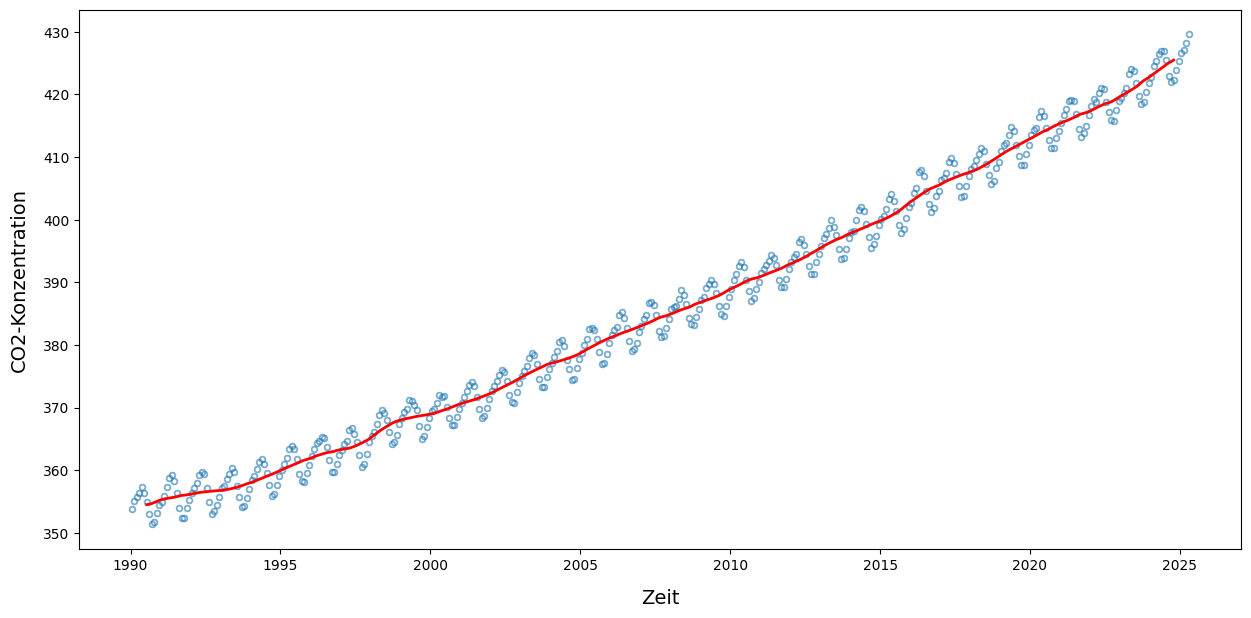

In [20]:
# Perdiodenlänge der saisonalen Schwankungen
L = 12

# Glättung mit gleitenden zentrierten Durchschnitten
CO2_smoothed = [1/L*(1/2 * df["average"].iloc[t - int(L/2)] + 
                     df["average"].iloc[t - int(L/2) + 1 : t + int(L/2)].sum() + 
                     1/2 * df["average"].iloc[t + int(L/2)]) 
                for t in range(int(L/2),df.shape[0]-int(L/2))]

# Figurobjekt erstellen
fig = plt.figure(figsize=(15,7))

# Koordinatensystem erstellen
axi = fig.add_subplot(1,1,1)

# Streudiagramm zeichnen
df.plot.scatter(x = "decimal date", y = "average", 
                ax = axi, marker="$\u25EF$",alpha=0.5)

# Geglätteten Datenpunkte zeichnen
x_trend = df["decimal date"][int(L/2):df.shape[0]-int(L/2)]
y_trend = np.array(CO2_smoothed) 
axi.plot(x_trend,y_trend,color="red",lw=2)

# Achsen beschriften
axi.set_xlabel("Zeit",size=14,labelpad=12)
axi.set_ylabel("CO2-Konzentration",size=14,labelpad=10)

# Figur zeigen
plt.show()

Beim gleitenden Durchschnitt werden alle Werte der Periode $\pmb{L}$ gleich stark gewichtet. Bei der **exponentiellen Glättung** werden die aktuellen Werte stärker gewichtet als ältere Beobachtungen, die exponentiell weniger Einfluss haben. Die geglätteten Werte können ***rekursiv*** berechnet werden: $$\pmb{\bar{y}(t)} \;=\; \pmb{\alpha\cdot y_t + (1-\alpha)\cdot\bar{y}(t-1)}$$

Der Parameter $\pmb{\alpha}$ heisst **Glättungsfaktor**. 
- Für $\pmb{\alpha}=1$ ist der Vorhersagewert gleich dem Messwert (keine Glättung)
- Für $\pmb{\alpha}=0$ ist der Vorhersagewert unverändert (Glättung zu einer Parallelen zur $x$-Achse)

In Abhängigkeit von $\,\pmb{\alpha}\,$ werden die Werte der Vergangenheit stärker oder schwächer berücksichtigt:

$$\begin{align*} \pmb{\bar{y}(1)} &= \pmb{\alpha\cdot \textcolor{red}{y(1)} + (1-\alpha)\cdot \textcolor{red}{y(0)}}\\
\pmb{\bar{y}(2)} &= \pmb{\alpha\cdot y(2) + (1-\alpha)\cdot\bar{y}(1)}\rule{0cm}{1cm}\\ 
 &= \pmb{\alpha\cdot y(2) + (1-\alpha)\cdot\left[\,\alpha\cdot y(1) + (1-\alpha)\cdot y(0)\right]}\,\rule{0cm}{1cm} \\ &= \pmb{\alpha\cdot \textcolor{red}{y(2)} + \alpha(1-\alpha)\cdot\textcolor{red}{y(1)} + (1-\alpha)^2\cdot \textcolor{red}{y(0)}}\,\rule{0cm}{1cm} \\
 \pmb{\bar{y}(3)} &= \pmb{\alpha\cdot \textcolor{red}{y(3)} + \alpha(1-\alpha)\cdot\textcolor{red}{y(2)} + \alpha(1-\alpha)^2\cdot \textcolor{red}{y(1)} + (1-\alpha)^3\cdot \textcolor{red}{y(0)}}\,\rule{0cm}{1cm} \\
&\;\;\vdots \rule{0cm}{1cm}\\
\pmb{\bar{y}(t)} &= \pmb{\alpha\cdot \textcolor{red}{y(t)} + \alpha(1-\alpha)\cdot\textcolor{red}{y(t-1)} + \alpha(1-\alpha)^2\cdot \textcolor{red}{y(t-2)} + \ldots + (1-\alpha)^t\cdot \textcolor{red}{y(0)}}\,\rule{0cm}{0.8cm}\\
&\;\;\vdots\end{align*}$$

Die Implementierung einer exponentiellen Glättung ist sehr einfach. 
- Wir können das **letzte Element** einer Python Liste mit dem **Index -1** abfragen: 

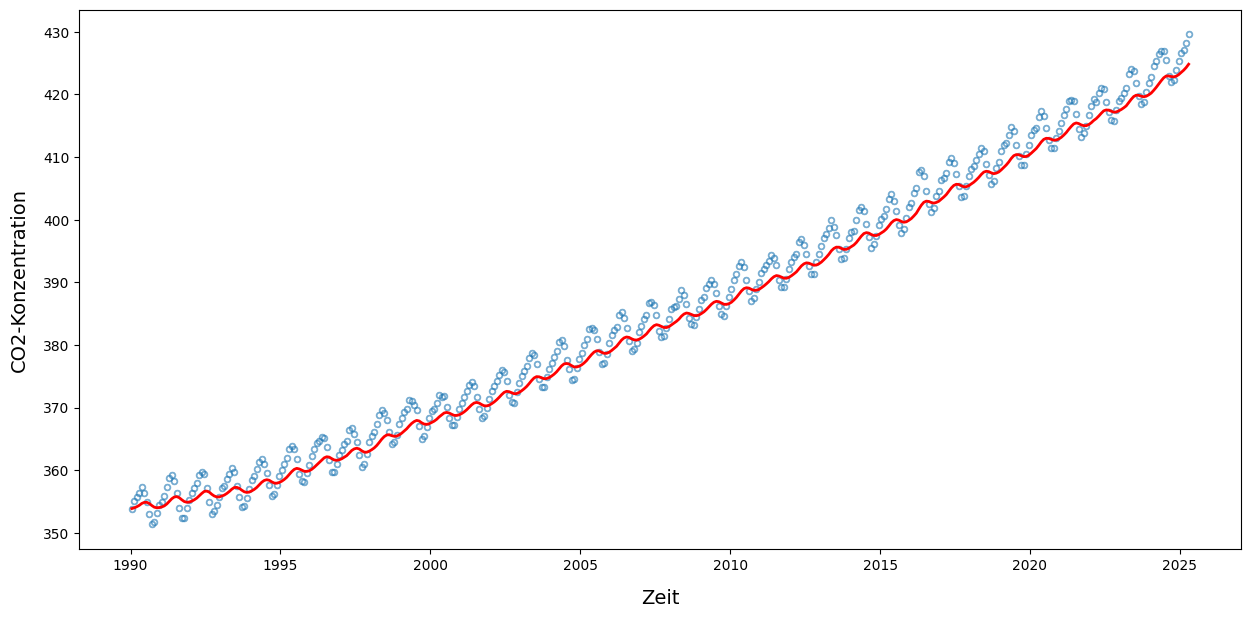

In [21]:
# Glättungsfaktor
alpha = 0.1

# exponentielle Glättung der CO2-Werte
CO2_smoothedExp = [df["average"].iloc[0]]
for i in range(1,df.shape[0]):
    nextValue = alpha * df["average"].iloc[i] + (1-alpha) * CO2_smoothedExp[-1]
    CO2_smoothedExp.append(nextValue)

# Figurobjekt erstellen
fig = plt.figure(figsize=(15,7))

# Koordinatensystem erstellen
axi = fig.add_subplot(1,1,1)

# Streudiagramm zeichnen
df.plot.scatter(x = "decimal date", y = "average", 
                ax = axi, marker="$\u25EF$",alpha=0.5)

# Geglätteten Datenpunkte zeichnen
x_trendExp = df["decimal date"]
y_trendExp = np.array(CO2_smoothedExp) 
axi.plot(x_trendExp,y_trendExp,color="red",lw=2)

# Achsen beschriften
axi.set_xlabel("Zeit",size=14,labelpad=12)
axi.set_ylabel("CO2-Konzentration",size=14,labelpad=10)

# Figur zeigen
plt.show()

### <span style="color:rgb(160,0,86)">Aufgabe 1</span>
Laden Sie die neusten $\mathsf{CO}_2$-Messungen vom **Global Monitoring Laboratory** herunter und vergleichen Sie die real gemessenen Werte mit unserer Prognose oben.

---

### <span style="color:rgb(160,0,86)">Lösungsvorschlag</span>

Statt die neusten Daten **selbst** von der Websete des *Global Monitoring Laboratory* **herunterzuladen**, können wir diesen Prozess **mit Python automatisieren**.

Das Modul **os** stellt Funktionen zur Verfügung, um **betriebssystemnahe Aufgaben** in Python zu erledigen. 
- Für den **Umgang mit Dateipfaden** und dem **Dateisystem** ist das Modul **os** sehr geeignet, da es Funktionen bereitstellt, mit denen sich **betriebssystemunabhängiger (portabler) Code** schreiben lässt, der unter Windows, macOS und Linux gleich funktioniert.

Für unsere Aufgabe brauchen wir die folgenden Funktionen:
- <tt><strong>os.makedirs(path, exist_ok=True)</strong></tt> erstellt ein Verzeichnis inklusive aller notwendigen Unterverzeichnisse.<br />
Mit dieser Funktion erzeugen wir im Ordner **Daten** einen neuen Ordner **Daten_aktuell** mit dem lokalen Pfad <tt><strong>"Daten/Daten_aktuell"</strong></tt>. Mit dem Parameter <tt><strong>exist_ok=True</strong></tt> wird kein Fehler geworfen, falls der Ordner bereits existiert
- <tt><strong>os.path.join(a,b,...)</strong></tt> setzt Dateipfade betriebssystemunabhängig zusammen. <br /> Warum erstellen wir den Pfad nicht einfach durch <tt><strong>"Daten/Daten_aktuell/" + filename</strong></tt>?
Windows nutzt als **Trennzeichen** **\\**, Linux und macOS nutzen hingegen **/**. Die Funktion <tt><strong>os.path.join</strong></tt> kümmert sich automatisch um das richtige Trennzeichen

Das Modul **requests** ist eine sehr verbreitete Bibliothek für **HTTP-Kommunikation** in Python, um zum Beispiel Dateien aus dem Internet herunterzuladen oder Webseiten automatisiert auszulesen. Das Modul ist sehr gut geeignet für die Datenbeschaffung in Data Science.

Für unsere Aufgabe brauchen wir die folgenden Funktionen:
- <tt><strong>requests.get(url)</strong></tt> sendet eine HTTP-GET-Anfrage an eine URL und gibt eine Antwort (Response-Objekt) zurück. <br /> Das **Response-Objekt** enthält unter anderem
  - einen **Statuscode** <tt><strong>response.status_code</strong></tt>, der beschreibt wie der Server auf die Anfrage reagiert hat,
  - den **Inhalt der Antwort** <tt><strong>response.content</strong></tt>  völlig formatunabhängig als Bytefolge (geeignet für CSV-Dateien, Bilder, PDFs, ZIP-Dateien, usw.) und
  - eine dekodierte **Textdarstellung des Inhalts** <tt><strong>response.text</strong></tt> als einen String (geeignet für HTML-Seiten, JSON-Antworten, einfache Textdateien, usw.).
- <tt><strong>response.raise_for_status()</strong></tt> überprüft, ob die HTTP-Anfrage erfolgreich war. <br /> Die Funktion wirft eine Exception bei Fehlercodes und ermöglicht ein Abbrechen bei Fehlern.

Mit dem Python-Code <tt><strong>with open(file_path, mode) as f</strong></tt> öffnen wir ein Dateiobjekt, das der Variablen **f** zugewiesen wird. Mit dem Parameter <tt><strong>mode</strong></tt> können wir angeben, dass eine Datei zum Schreiben geöffnet wir:
- mit <tt><strong>"wb"</strong></tt> für <tt><strong>mode</strong></tt> arbeiten wir im Binärmodus (wichtig für Downloads).<br /> <tt><strong>f.write(response.content)</strong></tt> speichert dann exakt die heruntergeladne Datei als Bytefolge in die geöffnete Datei.

Der <tt><strong>with</strong></tt>-Block sorgt dafür, dass die Datei automatisch wieder geschlossen wird.

In [22]:
import os
import requests

# Zielverzeichnis - Ordner Daten_aktuell im Ordner Daten erstellen
target_dir = "Daten/Daten_aktuell"
os.makedirs(target_dir, exist_ok=True)

# URL der CSV-Datei (monthly mean)
url = "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv"

# Download
response = requests.get(url)
response.raise_for_status()  # wirft Fehler bei HTTP-Problemen

# Zielpfad
file_path = os.path.join(target_dir, "co2_mm_mlo.csv")

# Datei speichern
with open(file_path, "wb") as f:
    f.write(response.content)

# Wenn alles ohne Fehler funktioniert hat
print(f"Datei erfolgreich gespeichert unter: {file_path}")

Datei erfolgreich gespeichert unter: Daten/Daten_aktuell\co2_mm_mlo.csv


Nun können wir die **neuen Daten laden** und **mit der Prognose vergleichen**:

In [23]:
#Mauna Loa CO2-Aufzeichnungen
import numpy as np
import pandas as pd
CO2_neu = pd.read_csv("Daten/Daten_aktuell/co2_mm_mlo.csv", comment="#")

CO2_neu.tail(8)

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
810,2025,9,2025.7083,424.37,427.77,19,0.48,0.21
811,2025,10,2025.7917,424.87,428.10,19,0.32,0.14
812,2025,11,2025.8750,426.46,428.42,20,0.69,0.30
813,2025,12,2025.9583,427.49,428.22,24,0.32,0.12
814,2026,1,2026.0417,428.62,428.34,25,0.69,0.27
815,2026,2,2026.1250,429.35,428.40,17,0.74,0.35
816,2026,3,2026.2083,430.15,428.72,26,0.86,0.32
817,2026,4,2026.2917,431.12,428.70,23,1.13,0.45


Nun schneiden wir wieder aus dem DataFrame die Spalten <tt>(year,month,decimal date,average)</tt> aus und filtern für den Vergleich die **Daten ab dem Jahr 2025 und Monat Mai**:

In [24]:
df_neu = CO2_neu[["year","month","decimal date","average"]][
                  CO2_neu["decimal date"]>=2025.3750]
df_neu

,year,month,decimal date,average
806,2025,5,2025.3750,430.51
807,2025,6,2025.4583,429.61
808,2025,7,2025.5417,427.87
809,2025,8,2025.6250,425.48
810,2025,9,2025.7083,424.37
811,2025,10,2025.7917,424.87
812,2025,11,2025.8750,426.46
813,2025,12,2025.9583,427.49
814,2026,1,2026.0417,428.62
815,2026,2,2026.1250,429.35


Die **tatsächlichen CO2-Werte** und die **Prognosen** stellen wir graphisch dar und geben zudem auch den Fehler aus:

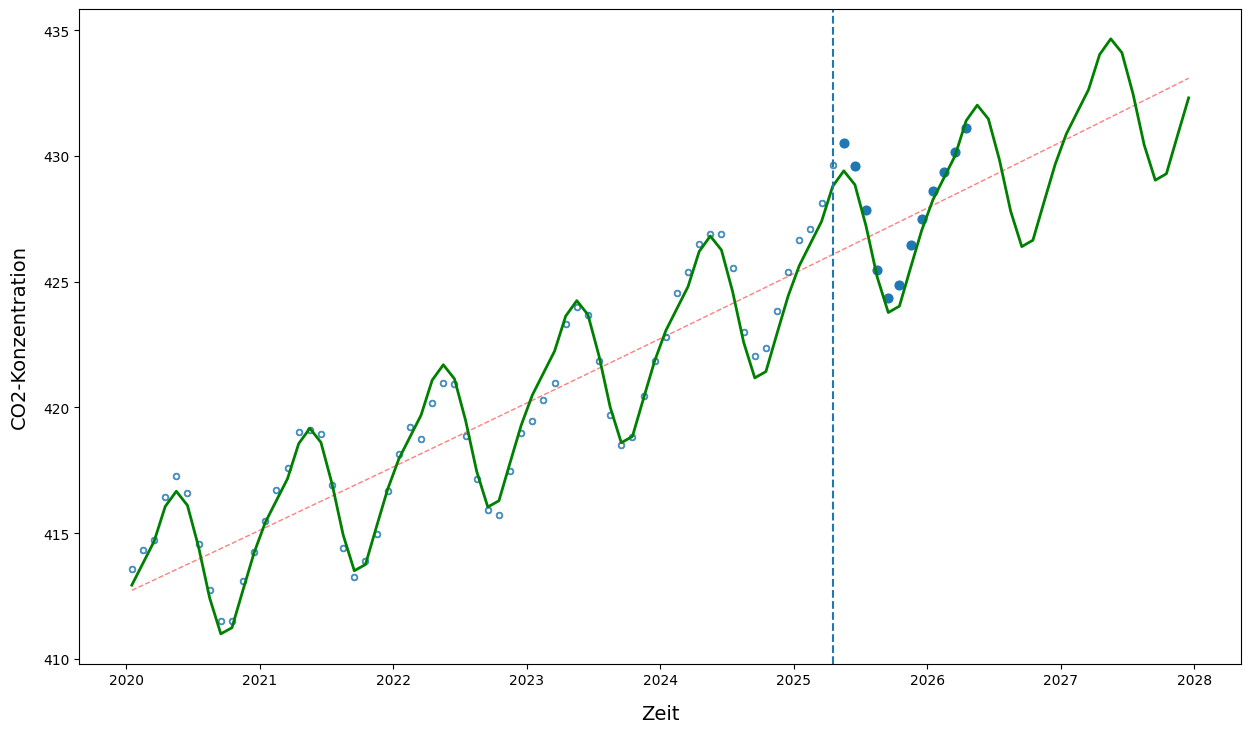


--- Residuen der neuen CO2-Werte zu den Schätzungen ---
Im Mai       2025 ist der Fehler +1.10 (+0.26%)
Im Juni      2025 ist der Fehler +0.75 (+0.17%)
Im Juli      2025 ist der Fehler +0.66 (+0.15%)
Im August    2025 ist der Fehler +0.29 (+0.07%)
Im September 2025 ist der Fehler +0.59 (+0.14%)
Im Oktober   2025 ist der Fehler +0.84 (+0.20%)
Im November  2025 ist der Fehler +0.91 (+0.21%)
Im Dezember  2025 ist der Fehler +0.45 (+0.11%)
Im Januar    2026 ist der Fehler +0.37 (+0.09%)
Im Februar   2026 ist der Fehler +0.22 (+0.05%)
Im März      2026 ist der Fehler +0.14 (+0.03%)
Im Apil      2026 ist der Fehler --0.29 (--0.07%)


In [25]:
# Figurobjekt erstellen
fig = plt.figure(figsize=(15,8.5))

# Koordinatensystem erstellen
axi = fig.add_subplot(1,1,1)

# Streudiagramm für die Daten zeichnen
df[df["year"]>=2020].plot.scatter(x = "decimal date", y = "average", 
                ax = axi, marker="$\u25EF$",alpha=0.75)
df_neu.plot.scatter(x = "decimal date", y = "average", 
                ax = axi, marker="$\u2022$",s=40)

# Koordinaten für geschätzte CO2-Werte (2020 bis Dezember 2034)
x_pred = np.round(np.arange(2020 + 1/24, 2028, 1/12), 4)
y_pred = predictCO2(x_pred)            # Trendlinie mit saisonaler Schwankung
y_trend_pred = predict_potenz(x_pred)  # nur Trendlinie

# Prognosen zeichnen
axi.plot(x_pred,y_trend_pred,color="red",linestyle="dashed",lw=1,alpha=0.5)
axi.plot(x_pred,y_pred,color="green",lw=2)

# vertikale Linie bei Zeit = April 2025
axi.axvline(2025+1/24+3/12,linestyle="dashed")

# Achsen beschriften
axi.set_xlabel("Zeit",size=14,labelpad=12)
axi.set_ylabel("CO2-Konzentration",size=14,labelpad=10)

# Figur zeigen
plt.show()

# Residuen ausgeben
monate = {1:"Januar",
          2:"Februar",
          3:"März",
          4:"Apil",
          5:"Mai",
          6:"Juni",
          7:"Juli",
          8:"August",
          9:"September",
          10:"Oktober",
          11:"November",
          12:"Dezember"}
print("\n--- Residuen der neuen CO2-Werte zu den Schätzungen ---")
for y, m, d, a in df_neu.values:
    r = a - predictCO2(np.array([d]))
    sign = "+" if r>=0 else "-"
    print(f"Im {monate[m]:<9} {int(y)} ist der Fehler {sign}{round(r[0],2):<4.2f} ({sign}{round(r[0]/a*100,2):.2f}%)")

Die **Schätzungen** waren alle **zu klein**, aber dennoch sehr genau. Der **maximale Fehler** beträgt **0.26%**.  

### <span style="color:rgb(160,0,86)">Aufgabe 2</span>
Machen Sie eine **Zeitreihenanalyse** für die Anzahl Fluggäste pro Monat an Berliner Flughäfen (beobachtet von Januar 2011 bis Dezember 2017). Die Daten finden sie in der Datei *Fluggaeste.sav* im Ordner Daten.

---

### <span style="color:rgb(160,0,86)">Lösungsvorschlag</span>

Wir **laden** die Daten in der **.sav** Datei mit der Funktion <tt><strong>read_spss()</strong></tt> aus dem Modul **pandas**:

In [102]:
# pip install pyreadstat
fluggaeste = pd.read_spss("Daten/Fluggaeste.sav")
fluggaeste.head()

,Zeit,Flug,YEAR_,MONTH_,DATE_
0,1.0,1547.0,2011.0,1.0,JAN 2011
1,2.0,1589.0,2011.0,2.0,FEB 2011
2,3.0,1880.0,2011.0,3.0,MAR 2011
3,4.0,1959.0,2011.0,4.0,APR 2011
4,5.0,2166.0,2011.0,5.0,MAY 2011


Damit wir die Zeitreihe analog zu den CO2-Werten analysieren können, ergängen wir im DataFrame eine Spalte mit **dezimalen Daten**:

In [106]:
fluggaeste["decimal date"] = round(fluggaeste["YEAR_"] + 1/24
                                   + (fluggaeste["MONTH_"]-1)/12,4)
fluggaeste.head()

,Zeit,Flug,YEAR_,MONTH_,DATE_,decimal date
0,1.0,1547.0,2011.0,1.0,JAN 2011,2011.0417
1,2.0,1589.0,2011.0,2.0,FEB 2011,2011.1250
2,3.0,1880.0,2011.0,3.0,MAR 2011,2011.2083
3,4.0,1959.0,2011.0,4.0,APR 2011,2011.2917
4,5.0,2166.0,2011.0,5.0,MAY 2011,2011.3750


Für einen ersten Überblick zeichnen die Zeitreihe in einem **Streudiagramm**:

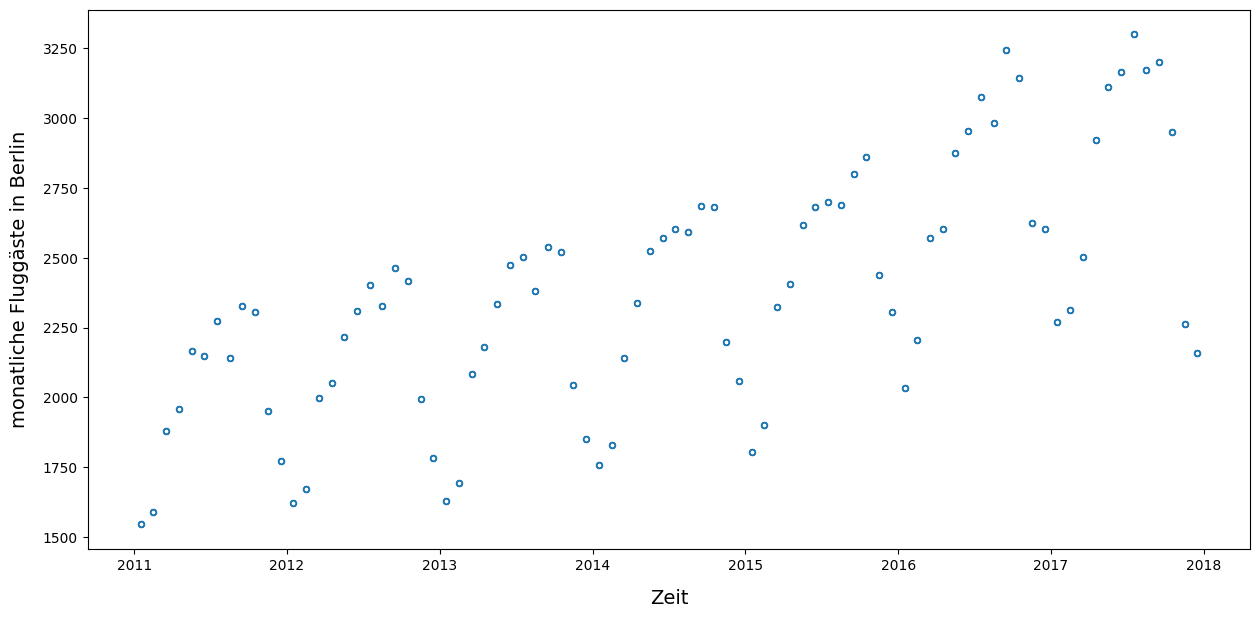

In [130]:
import matplotlib.pyplot as plt

# Figurobjekt erstellen
fig = plt.figure(figsize=(15,7))

# Koordinatensystem erstellen
axi = fig.add_subplot(1,1,1)

# Streudiagramm zeichen
fluggaeste.plot.scatter(x="decimal date",y="Flug",ax=axi,marker="$\u25EF$")

# Achsen beschriften
axi.set_xlabel("Zeit",size=14,labelpad=12)
axi.set_ylabel("monatliche Fluggäste in Berlin",size=14,labelpad=10)

# Figur zeigen
plt.show()

Wir bestimmen wieder mit der Methode der kleinsten Quadarte das **lineare Modell** und ein **Modell mit einer Potenzfuntion**:

In [108]:
from scipy.optimize import minimize 

# Fluggäste = a * Zeit + b (linear)
def model_linear(time,a=1,b=0):
    
    return a*time + b

# Fluggäste = a * Zeit^r + b (potenz)
def model_potenz(time,a=1,r=1,b=0): 
    return a*(time**r) + b

# Zeitverschiebung => kleinere Werte
t = fluggaeste["decimal date"] - 2010

# parameter = [a,b]
def RSS_linear(parameter):
    residuen = fluggaeste["Flug"] - model_linear(t,a=parameter[0],
                                                   b=parameter[1])
    return (residuen**2).sum()

# parameter = [a,r,b]
def RSS_potenz(parameter):
    residuen = fluggaeste["Flug"] - model_potenz(t,a=parameter[0],
                                                   r=parameter[1],
                                                   b=parameter[2])
    return (residuen**2).sum()    

# Berechne die Parameter für das lineare Modell
fit_linear = minimize(RSS_linear,x0=[0,0],method = 'powell')
print("Minimierung RSS_linear war erfolgreich:",fit_linear.success)

# Berechne die Parameter für das Modell mit der Potenzfunktion
fit_potenz = minimize(RSS_potenz,x0=[1,1,300],method = 'powell')
print("Minimierung RSS_potenz war erfolgreich:",fit_potenz.success)

Minimierung RSS_linear war erfolgreich: True
Minimierung RSS_potenz war erfolgreich: True


Nun zeichnen wir die **Daten** und **beide Modelle**: 

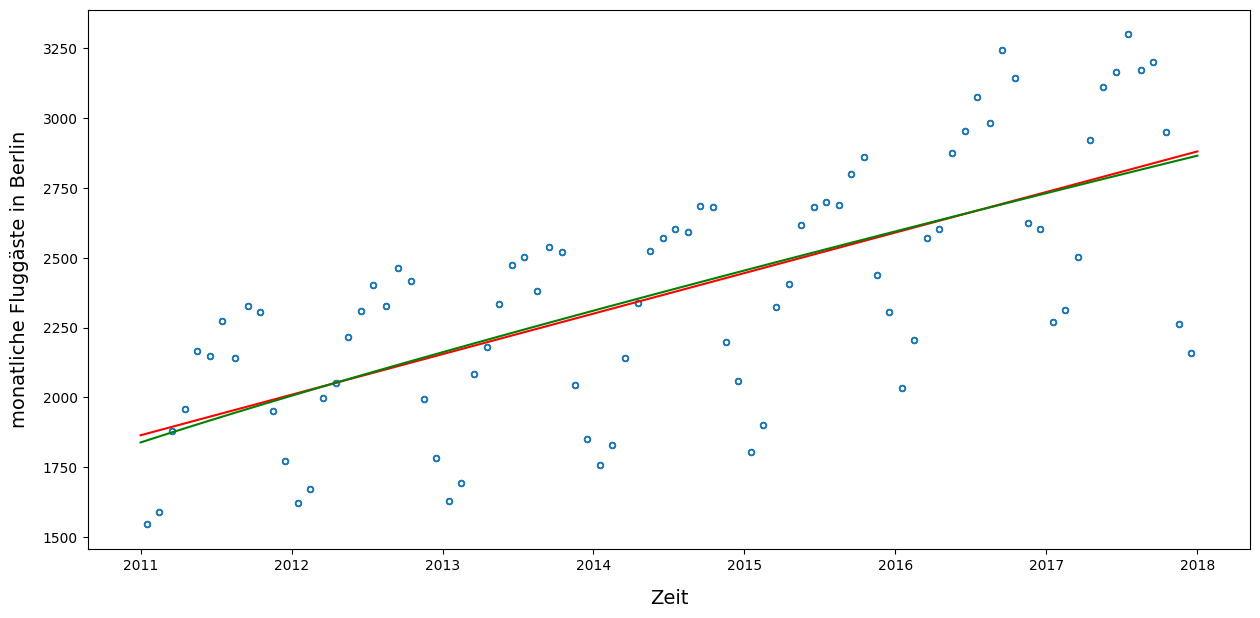

In [109]:
# Anzahl Fluggäste mit linearem Modell schätzen
def predict_linear(x):
    return model_linear(x - 2010,a=fit_linear.x[0],
                                 b=fit_linear.x[1])

# Anzahl Fluggäste mit Potenzfunktion als Modell schätzen
def predict_potenz(x):
    return model_potenz(x - 2010,a=fit_potenz.x[0],
                                 r=fit_potenz.x[1],
                                 b=fit_potenz.x[2])

# Figurobjekt erstellen
fig = plt.figure(figsize=(15,7))

# Koordinatensystem erestellen
axi = fig.add_subplot(1,1,1)

# Streudiagramm für die Anzahl Fluggäste zeichen
fluggaeste.plot.scatter(x = "decimal date", y = "Flug", 
                        ax = axi, marker="$\u25EF$")

# Koordinaten für die historischen Daten zeichnen
x = np.linspace(2011,2018,100)
y_lin = predict_linear(x) # lineare Funktion
y_pot = predict_potenz(x) # Potenzfunktion
axi.plot(x,y_lin,color="red",lw=1.5)
axi.plot(x,y_pot,color="green",lw=1.5)

# Achsen beschriften
axi.set_xlabel("Zeit",size=14,labelpad=12)
axi.set_ylabel("monatliche Fluggäste in Berlin",size=14,labelpad=10)

# Figur zeigen
plt.show()

Die zwei Modelle scheinen sich kaum zu unterscheiden. Wir berechnen das **Bestimmtheitsmass** für beide Modelle:

In [111]:
R_squared_linear = (predict_linear(fluggaeste["decimal date"]).var() / 
                    fluggaeste["Flug"].var()) 
R_squared_potenz = (predict_potenz(fluggaeste["decimal date"]).var() / 
                    fluggaeste["Flug"].var())

print("Bestimmtheitsmass für das lin-Modell:", round(R_squared_linear,4))
print("Bestimmtheitsmass für das pot-Modell:", round(R_squared_potenz,4))

Bestimmtheitsmass für das lin-Modell: 0.4622
Bestimmtheitsmass für das pot-Modell: 0.4639


Der Unterschied ist so klein, dass wir mit dem einfacheren **linearen Modell** weiterrechnen. 

Die saisonalen Schwankungen haben erwartungsgemäss eine Periode von einem Jahr. Wie bestimmen die **mittleren Residuen für alle Monate**: 

In [118]:
# Residuen im DataFrame als weiter Spalte ergänzen
fluggaeste["residum"] = (fluggaeste["Flug"] - 
                         predict_linear(fluggaeste["decimal date"]) )

# mittlere Residuen für alle Monate
means = [fluggaeste["residum"][fluggaeste["MONTH_"].astype('Int64')==i].mean() 
         for i in range(1,13)]

means

[np.float64(-497.3954043413415),
 np.float64(-431.6225874655095),
 np.float64(-115.9926277325344),
 np.float64(9.479967863611591),
 np.float64(194.6813561680153),
 np.float64(247.59703018670442),
 np.float64(314.9267686399936),
 np.float64(221.12815694439698),
 np.float64(348.7581166773719),
 np.float64(282.0878551306613),
 np.float64(-210.5678994220781),
 np.float64(-363.08079683196047)]

Wir implementieren nun die **Prädiktorfunktion** für die Anzahl Fluggäste mit Berücksichtigung der saisonalen Schwankungen:

In [119]:
def predictFluggaeste(decimalDate):
    # Trend berechnen
    trend  = predict_linear(decimalDate)
    
    # Dezimalwert des ersten Monats bestimmen
    decimalMonat = decimalDate[0] - np.floor(decimalDate[0])
    
    # Index des ersten Monats bestimmen
    ersterIdx = int(round(12 * decimalMonat - 1/2,0))
    
    # saisonale Schwankung berechnen
    season = np.array([means[(ersterIdx + i)%12] 
                       for i in range(len(decimalDate))])
    
    return trend + season

Damit können wir zu den **historischen Daten** auch die **Schätzungen** zeichnen:

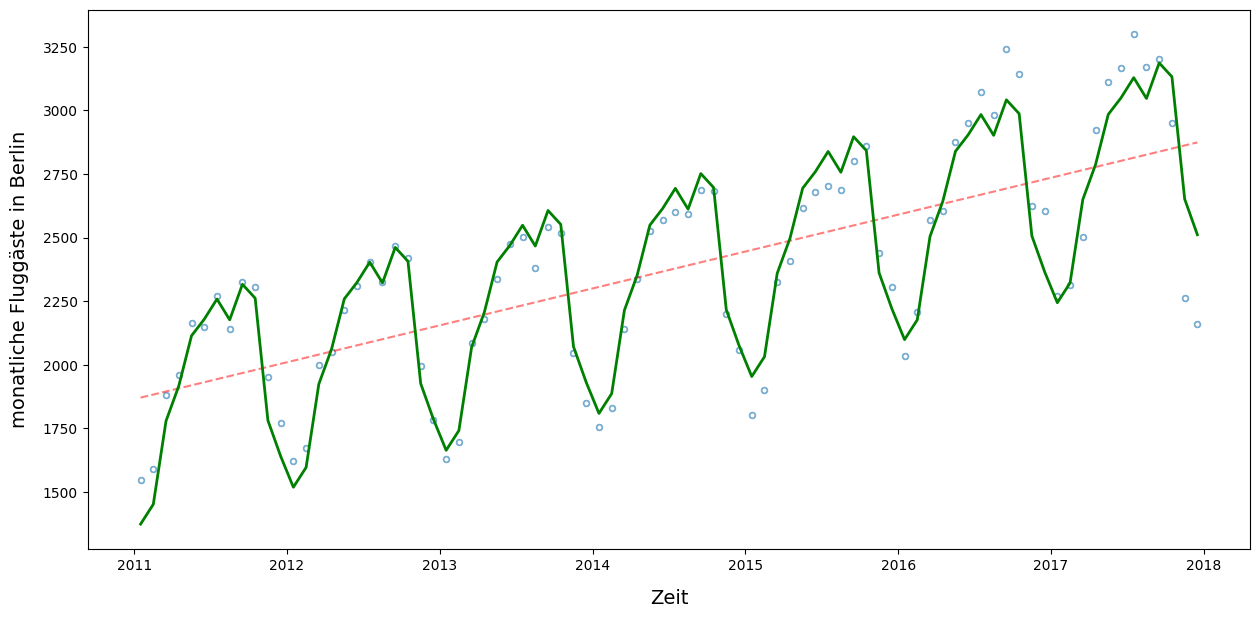

In [129]:
# Figurobjekt erstellen
fig = plt.figure(figsize=(15,7))

# Koordinatensystem erstellen
axi = fig.add_subplot(1,1,1)

# Streudiagramm für die historischen Daten zeichnen
fluggaeste.plot.scatter(x = "decimal date", y = "Flug", 
                        ax = axi, marker="$\u25EF$",alpha=0.5)

# Koordinaten der Schätzungen berechnen
x = fluggaeste["decimal date"].values
y = predictFluggaeste(x)     # Trendlinie mit saisonaler Schwankung
y_trend = predict_linear(x)  # nur Trendlinie

# Schätzungen zeichnen
axi.plot(x,y_trend,color="red",linestyle="dashed",lw=1.5,alpha=0.5)
axi.plot(x,y,color="green",lw=2)

# Achsen beschriften
axi.set_xlabel("Zeit",size=14,labelpad=12)
axi.set_ylabel("monatliche Fluggäste in Berlin",size=14,labelpad=10)

# Figur zeigen
plt.show()

Wir bestimmen das **Bestimmtheitsmass** für das Modell mit saisonalen Schwankungen:

In [122]:
# Bestimmtheitsmass ohne saisonale Schwankung
R_squared_trend = (predict_linear(fluggaeste["decimal date"]).var() / 
                                  fluggaeste["Flug"].var() )

# Bestimmtheitsmass mit saisonale Schwankung
R_squared_Flug = (predictFluggaeste(fluggaeste["decimal date"].values).var() / 
                                    fluggaeste["Flug"].var() )

print("Bestimmtheitsmass ohne saisonaler Schwankung :",round(R_squared_trend,4))
print("Bestimmtheitsmass mit saisonaler Schwankung  :",round(R_squared_Flug,4))

Bestimmtheitsmass ohne saisonaler Schwankung : 0.4622
Bestimmtheitsmass mit saisonaler Schwankung  : 0.9748


![HSLU](Bilder/LogoHSLU.png)